In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
Data = pd.read_csv("data/regression_df.csv")

In [3]:
Data = Data[Data['final_result']!='GGG']

<Axes: >

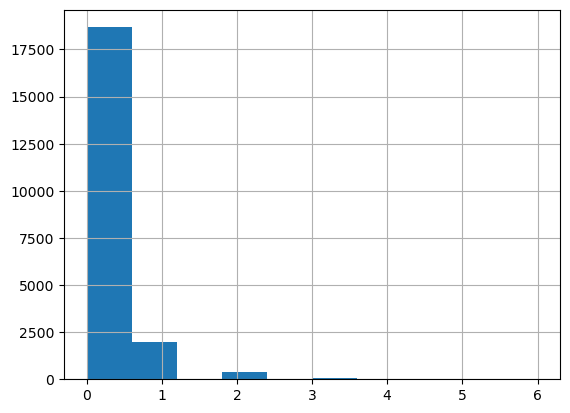

In [4]:
Data['num_of_prev_attempts'].hist()

In [5]:
Data = Data.drop(['imd_band','region','final_result'],axis=1)
Data = Data.drop(['date_unregistration'],axis=1)
Data['score'] = Data.apply(
    lambda x: x['score'] * 0.5 if x['code_module'] in ['CCC', 'DDD'] else x['score'],
    axis=1
)
Data = Data.drop(['code_module','id_student',],axis=1)


In [6]:
def Year_and_semester_extractor(Data: pd.DataFrame):
    df = Data.copy()
    df["presentation_year"] = df["code_presentation"].str[:4].astype(int)
    df["presentation_semester"] = df["code_presentation"].str[-1]
    df.drop(["code_presentation"],axis=1,inplace=True)
    return df
Data = Year_and_semester_extractor(Data)

In [7]:
X = Data.drop(['score'],axis=1)
y = Data['score']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


In [9]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 14805 entries, 19981 to 15795
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 14805 non-null  str    
 1   highest_education      14805 non-null  str    
 2   age_band               14805 non-null  str    
 3   num_of_prev_attempts   14805 non-null  int64  
 4   studied_credits        14805 non-null  int64  
 5   disability             14805 non-null  str    
 6   date_registration      14805 non-null  float64
 7   is_banked              14805 non-null  int64  
 8   total_clicks           14783 non-null  float64
 9   activity_diversity     14783 non-null  float64
 10  presentation_year      14805 non-null  int64  
 11  presentation_semester  14805 non-null  str    
dtypes: float64(3), int64(4), str(5)
memory usage: 1.9 MB


In [10]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

cols = ["total_clicks", "activity_diversity","studied_credits"]

# Fit on TRAIN only
X_train[cols] = imputer.fit_transform(X_train[cols])

# Transform TEST
X_test[cols] = imputer.transform(X_test[cols])

In [11]:
X_train[cols] = X_train[cols].apply(lambda x: np.log1p(x))
X_test[cols] = X_test[cols].apply(lambda x: np.log1p(x))

In [12]:
from sklearn.preprocessing import OrdinalEncoder
edu_order = [
    "No Formal quals",
    "Lower Than A Level",
    "A Level or Equivalent",
    "HE Qualification",
    "Post Graduate Qualification"
]

encoder = OrdinalEncoder(categories=[edu_order])

X_train["highest_education_encoded"] = encoder.fit_transform(
    X_train[["highest_education"]]
) + 1

X_test["highest_education_encoded"] = encoder.transform(
    X_test[["highest_education"]]
) + 1
X_train = X_train.drop(['highest_education'],axis=1)
X_test = X_test.drop(['highest_education'],axis=1)

In [13]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
disability_encoder = LabelEncoder()
semester_encoder = LabelEncoder()
# Fit on TRAIN
X_train["gender"] = gender_encoder.fit_transform(X_train["gender"])
X_train["disability"] = disability_encoder.fit_transform(X_train["disability"])
X_train['presentation_semester'] = semester_encoder.fit_transform(X_train["presentation_semester"])
# Transform TEST using same encoders
X_test["gender"] = gender_encoder.transform(X_test["gender"])
X_test["disability"] = disability_encoder.transform(X_test["disability"])
X_test['presentation_semester'] = semester_encoder.transform(X_test["presentation_semester"])

In [14]:
from sklearn.preprocessing import OneHotEncoder

age_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Fit on TRAIN only
age_ohe_train = age_encoder.fit_transform(X_train[["age_band"]])
age_ohe_test = age_encoder.transform(X_test[["age_band"]])

# Convert to DataFrames with column names
age_ohe_train_df = pd.DataFrame(
    age_ohe_train,
    columns=age_encoder.get_feature_names_out(["age_band"]),
    index=X_train.index
)

age_ohe_test_df = pd.DataFrame(
    age_ohe_test,
    columns=age_encoder.get_feature_names_out(["age_band"]),
    index=X_test.index
)

# Drop original column and join encoded ones
X_train = X_train.drop(columns=["age_band"]).join(age_ohe_train_df)
X_test = X_test.drop(columns=["age_band"]).join(age_ohe_test_df)


In [15]:
"""from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X_train)

train_probs = gmm.predict_proba(X_train)
test_probs  = gmm.predict_proba(X_test)

for i in range(train_probs.shape[1]):
    X_train[f'gmm_prob_{i}'] = train_probs[:, i]
    X_test[f'gmm_prob_{i}']  = test_probs[:, i]
"""

"from sklearn.mixture import GaussianMixture\n\ngmm = GaussianMixture(n_components=4, random_state=42)\ngmm.fit(X_train)\n\ntrain_probs = gmm.predict_proba(X_train)\ntest_probs  = gmm.predict_proba(X_test)\n\nfor i in range(train_probs.shape[1]):\n    X_train[f'gmm_prob_{i}'] = train_probs[:, i]\n    X_test[f'gmm_prob_{i}']  = test_probs[:, i]\n"

In [16]:
X_train

,gender,num_of_prev_attempts,studied_credits,disability,date_registration,is_banked,total_clicks,activity_diversity,presentation_year,presentation_semester,highest_education_encoded,age_band_0-35,age_band_35-55,age_band_55<=
19981,0,0,3.433987,0,-67.0,0,7.313887,2.079442,2014,0,2.0,1.0,0.0,0.0
4039,1,0,4.110874,0,-71.0,0,5.517453,2.079442,2014,0,2.0,0.0,1.0,0.0
14644,1,0,4.110874,0,-106.0,0,8.088869,2.639057,2013,0,3.0,1.0,0.0,0.0
18283,1,0,5.017280,0,-142.0,0,6.535241,2.302585,2014,1,3.0,1.0,0.0,0.0
20338,0,0,3.433987,0,-28.0,0,5.347108,2.079442,2014,0,2.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,1,0,4.110874,0,-99.0,0,6.202536,2.302585,2014,1,3.0,1.0,0.0,0.0
11964,0,1,4.795791,0,-116.0,0,6.919684,2.197225,2014,1,3.0,1.0,0.0,0.0
5390,0,0,4.110874,0,-56.0,0,6.666957,2.397895,2014,1,3.0,1.0,0.0,0.0
860,0,1,4.110874,0,-80.0,0,6.632002,2.302585,2013,0,4.0,0.0,1.0,0.0


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1️⃣ Define features & target
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

y_train_lr = y_train.copy()
y_test_lr = y_test.copy()

# 2️⃣ Train model
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

# 3️⃣ Predict
y_train_pred = lr_model.predict(X_train_lr)
y_test_pred = lr_model.predict(X_test_lr)

# 4️⃣ Evaluate with R²
train_r2 = r2_score(y_train_lr, y_train_pred)
test_r2 = r2_score(y_test_lr, y_test_pred)

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²:  {test_r2:.4f}")

Train R²: 0.4208
Test R²:  0.4124


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

regressor = RandomForestRegressor(n_estimators=1000, random_state=42, oob_score=True)
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

R-squared: 0.5893780031049604


In [22]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize XGBoost Regressor
regressor =XGBRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=5,
    random_state=42
)
# Fit the model
regressor.fit(X_train, y_train)

# Make predictions
y_pred = regressor.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

R-squared: 0.612416951836569


In [32]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
estimators = [
    ("rf", RandomForestRegressor(n_estimators=1000, max_depth=10, random_state=42)),
    ("xgb", XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5, random_state=42))
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Lasso(alpha=2.0),
    cv=5,
    passthrough=True,
    n_jobs=-1
)
stack.fit(X_train, y_train)

# Predict
y_pred = stack.predict(X_test)

# Evaluate
from sklearn.metrics import r2_score
print("Test R2:", r2_score(y_test, y_pred))

Test R2: 0.6131266829000546
